In [4]:
import numpy as np
from astropy.io import fits
from astropy.table import Table 
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 
import numpy as np
from astropy.cosmology import Planck18 as cosmo  # O FlatLambdaCDM se preferisci parametri custom
from astropy import units as u

/home/elettra/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [5]:
#open the file
qsolist = fits.open('MAGG_spectra_merged.fits')
num_qso = len(qsolist)-1

for exx in range(num_qso):
    #print files name and quasar redshift
    print(qsolist[exx+1].header['FIELD'])
    print(qsolist[exx+1].header['z_QSO'])


J010619.24+004823.3
4.4402
J012403.77+004432.7
3.8359
J013340.31+040059.7
4.1709
J013724.36-422417.3
3.975
J015741.56-010629.6
3.5645
J020944.61+051713.6
4.1846
J024401.84-013403.7
4.044
J033413.42-161205.4
4.38
J033900.98-013317.7
3.204
J094932.26+033531.7
4.1072
J095852.19+120245.0
3.2746
J102009.99+104002.7
3.1528
J111008.61+024458.0
4.1582
J111113.79-080402.0
3.93
J120917.93+113830.3
3.0836
J123055.57-113909.3
3.557
J124957.23-015928.8
3.6337
J133254.51+005250.6
3.5071
J142438.10+225600.7
3.634
J162116.92-004250.8
3.71
J193957.25-100241.5
3.787
J200324.14-325144.8
3.785
J205344.72-354655.2
3.49
J221527.29-161133.0
4.0
J230301.45-093930.7
3.4774
J231543.56+145606.4
3.3971
J233446.40-090812.2
3.3261
J234913.75-371259.2
4.24


/tmp/ipykernel_27166/2331191473.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


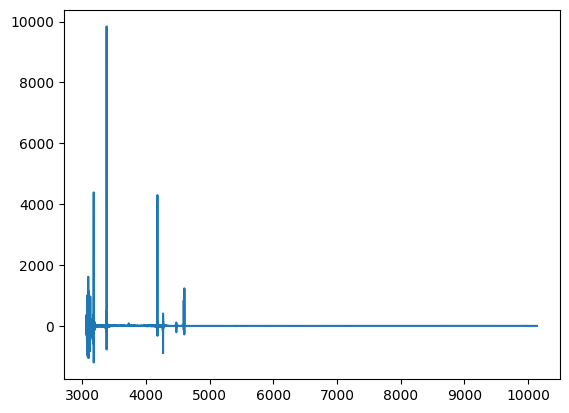

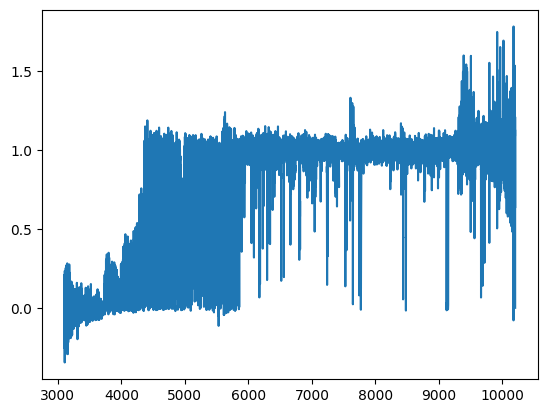

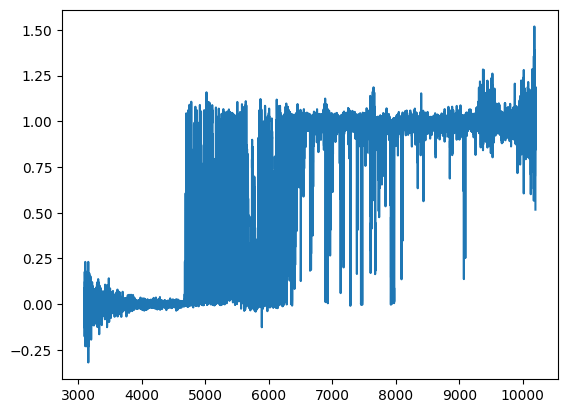

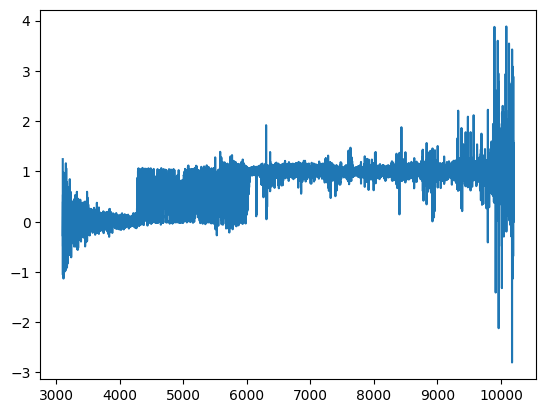

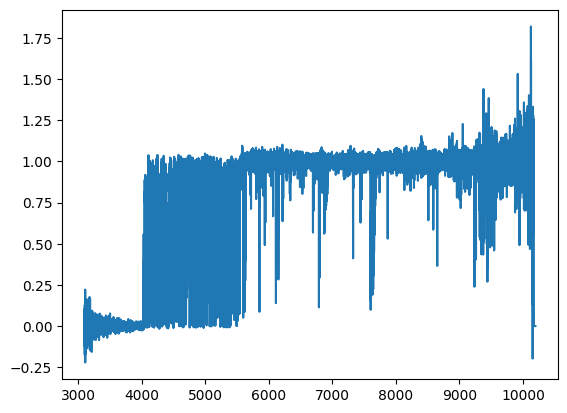

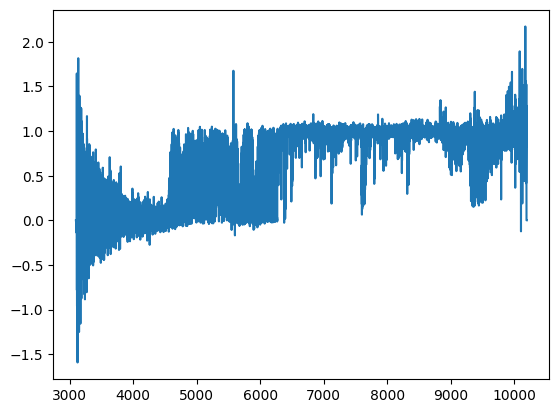

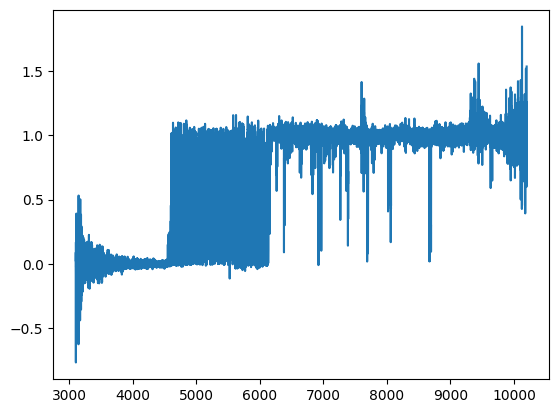

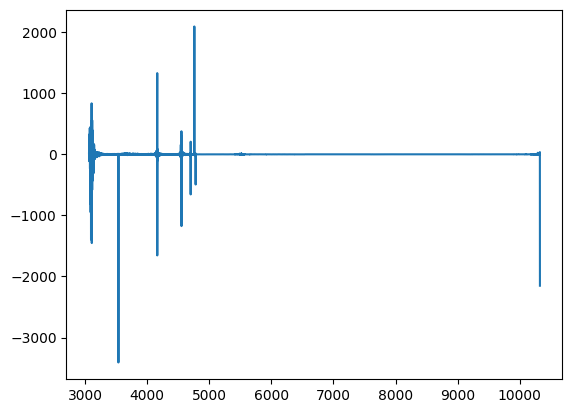

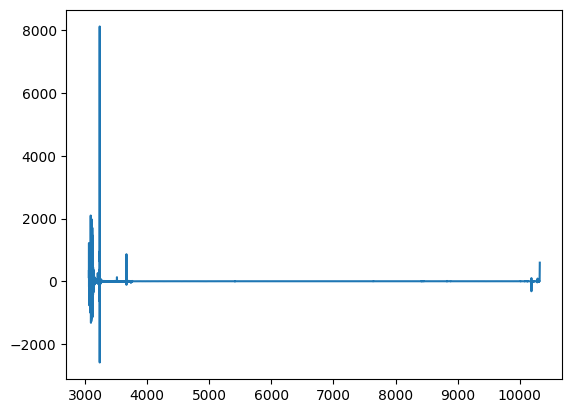

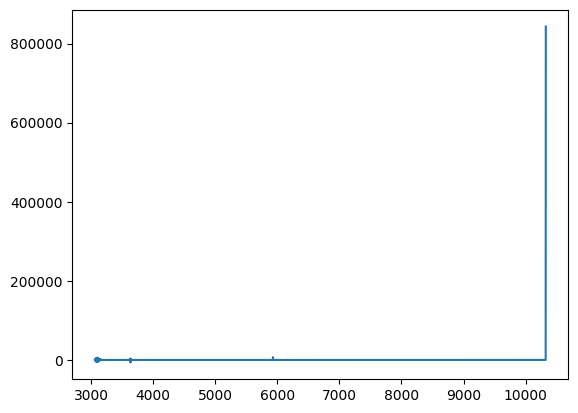

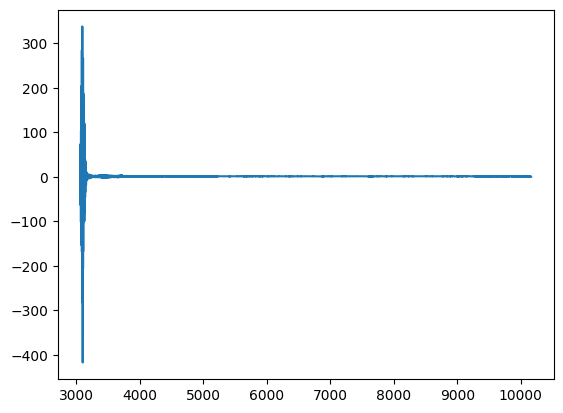

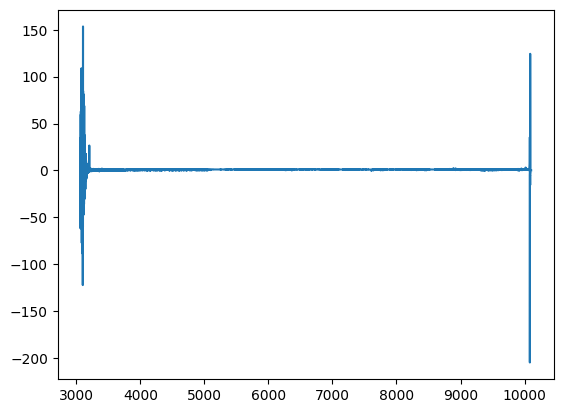

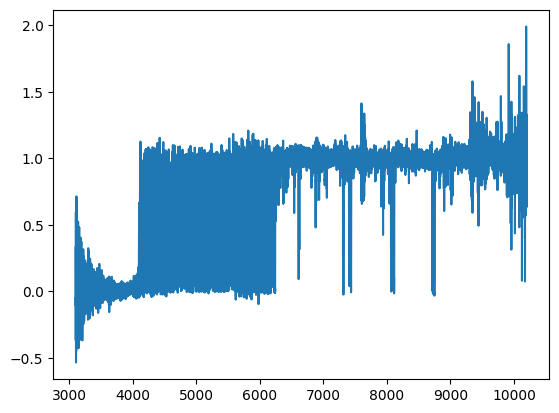

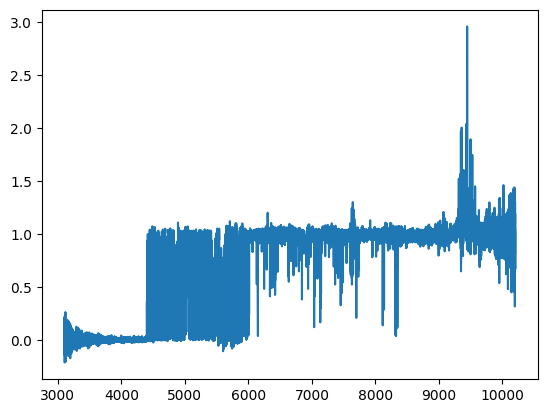

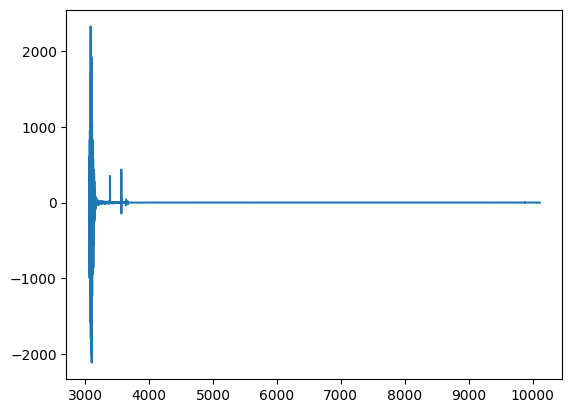

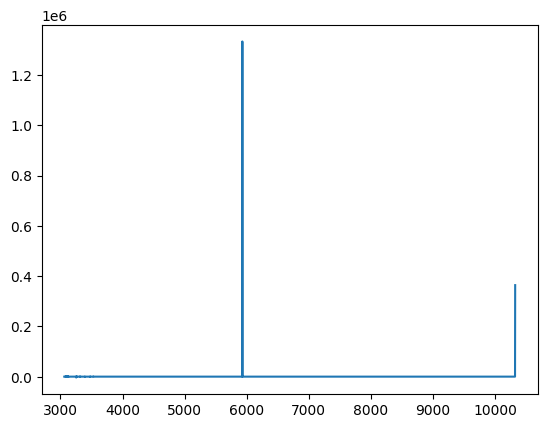

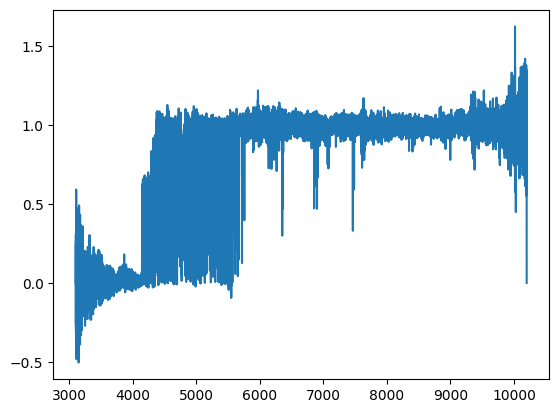

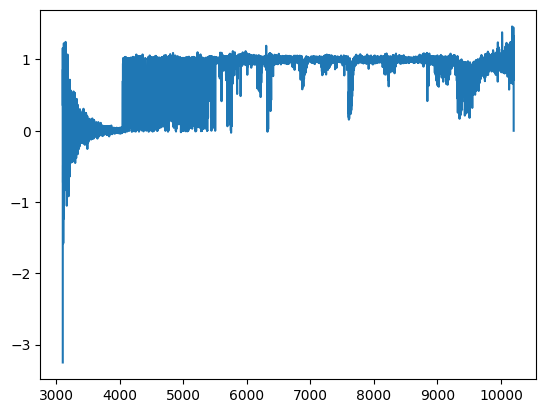

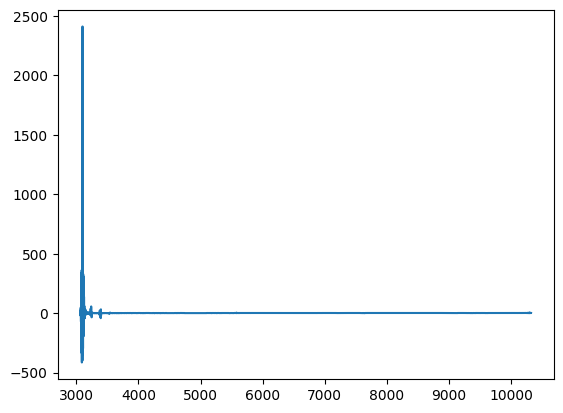

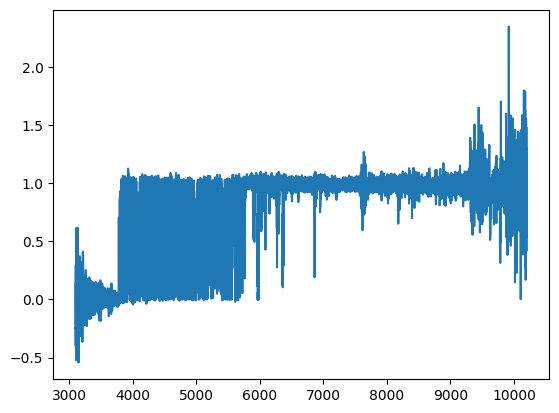

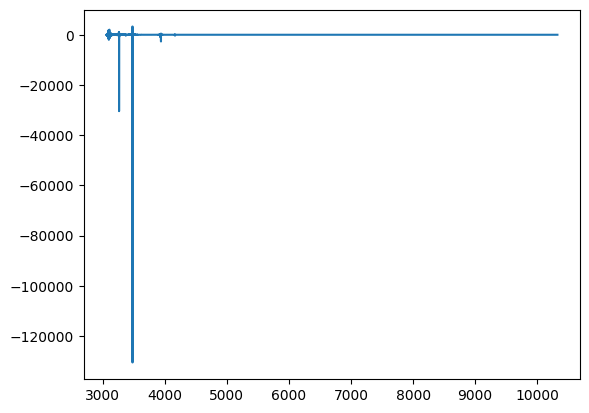

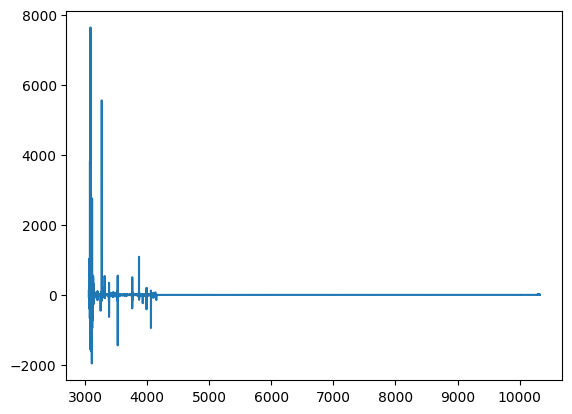

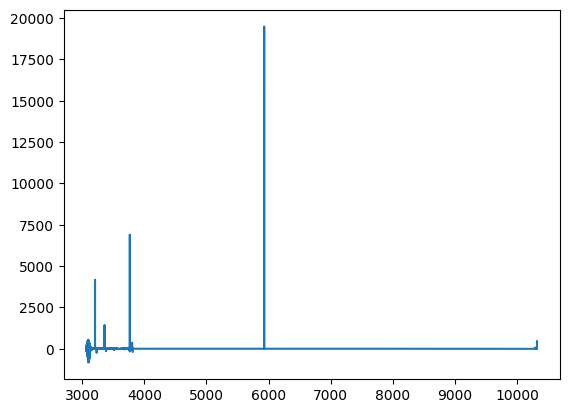

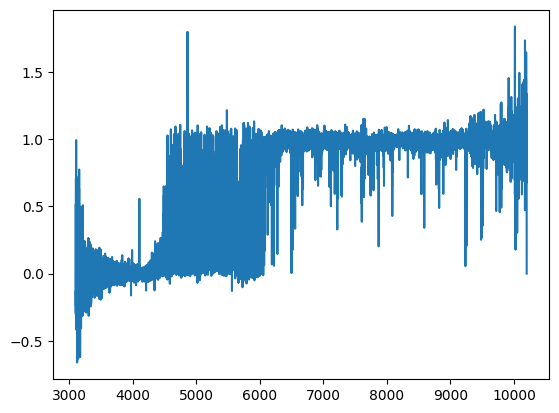

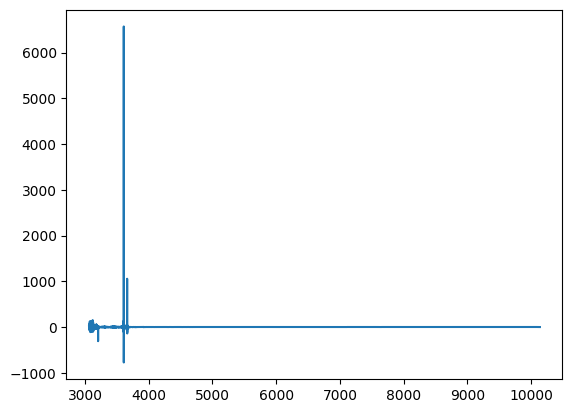

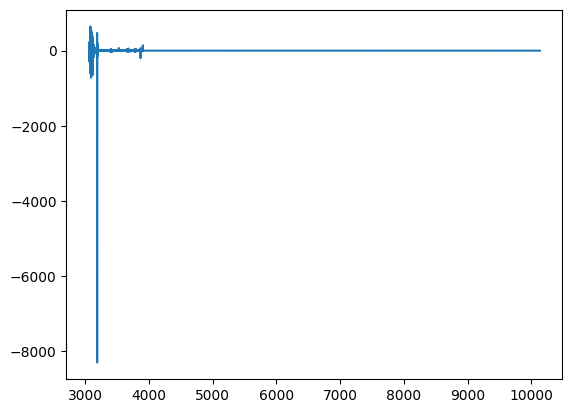

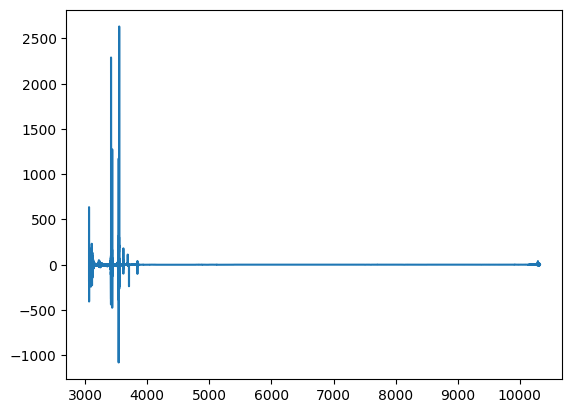

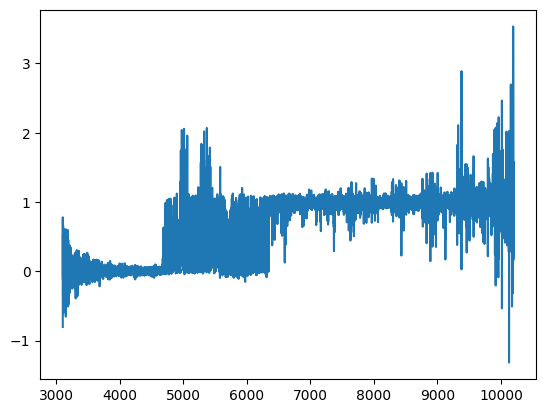

In [6]:
#plot the spectrum
for exx in range(num_qso):
    plt.figure()
    plt.plot(qsolist[exx+1].data['wave'], qsolist[exx+1].data['flux'])


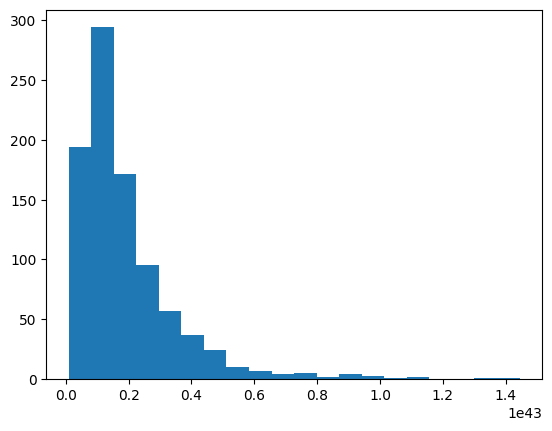

In [7]:
#histogram of the LAE luminosity

lae = Table.read('MAGG_LAEs.fits')

plt.figure()
plt.hist(lae['Lum'], bins= 20)
plt.show()

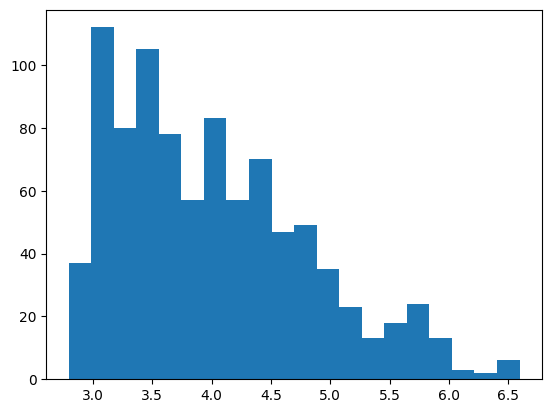

In [8]:
plt.figure()
plt.hist(lae['z_corr'], bins= 20)
plt.show()

In [9]:
print(lae)

       FIELD              z       ...         LumErr        
------------------- ------------- ... ----------------------
J010619.24+004823.3      2.926344 ...  7.945311826009941e+40
J010619.24+004823.3 3.10823812893 ... 1.0097005994398644e+41
J010619.24+004823.3 3.12134996922 ...  9.639746500686158e+40
J010619.24+004823.3 3.20808559003 ...  8.957599905770926e+40
J010619.24+004823.3    3.21117682 ... 1.5087090345596136e+41
J010619.24+004823.3        3.2247 ...  1.569898366629773e+41
J010619.24+004823.3       3.27537 ... 1.6622059749643417e+41
J010619.24+004823.3        3.3267 ...  1.772353031854091e+41
J010619.24+004823.3       3.32725 ... 2.8259290851745787e+41
J010619.24+004823.3        3.3276 ... 1.6414110933974275e+41
                ...           ... ...                    ...
J234913.75-371259.2      4.303664 ... 2.3417530430861282e+41
J234913.75-371259.2 4.38423212931 ... 2.2509935766450925e+41
J234913.75-371259.2     4.3840295 ... 1.9886266061028305e+41
J234913.75-371259.2     

In [13]:
print(qsolist[2].data['wave'])


[ 3100.02978516  3100.23632812  3100.44384766 ... 10199.18359375
 10199.55371094 10199.92285156]


/tmp/ipykernel_27166/2541084951.py:5: RuntimeWarning: divide by zero encountered in log
  tau = -np.log(flux)
/tmp/ipykernel_27166/2541084951.py:5: RuntimeWarning: invalid value encountered in log
  tau = -np.log(flux)


Text(0, 0.5, 'tau')

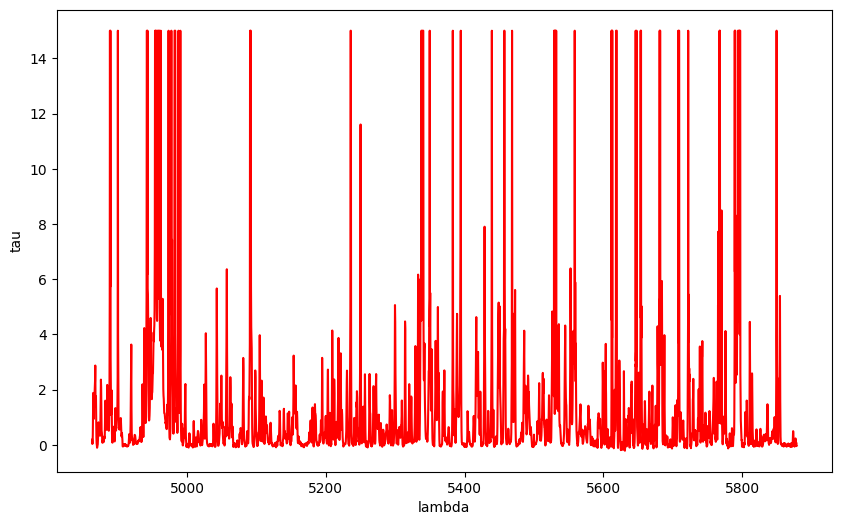

In [35]:
landa = qsolist[2].data['wave']
flux = qsolist[2].data['flux']

#with np.errstate(invalid='ignore', divide='ignore'):
tau = -np.log(flux) 

tau[flux < 0] = 15

zmin = 3.0
zmax = qsolist[2].header['z_QSO'] 

lyman_alpha = 1215.67
landa_min_limit = lyman_alpha * (1 + zmin)
landa_max_limit = lyman_alpha * (1 + zmax)

mask = (landa > landa_min_limit) & (landa < landa_max_limit)

landa_masked = landa[mask]
tau_masked = tau[mask]

plt.figure(figsize=(10, 6))
plt.plot(landa_masked, tau_masked, color='red')
plt.xlabel('lambda')
plt.ylabel('tau')

Text(0, 0.5, 'tau')

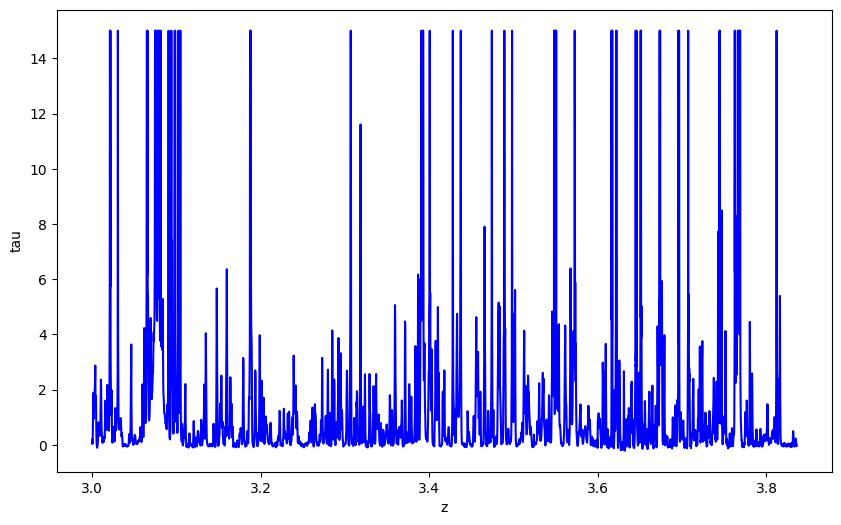

In [34]:
z = landa/(1215.67) - 1

mask_z = (z > zmin) & (z < zmax)
z_masked = z[mask_z]

plt.figure(figsize=(10, 6))
plt.plot(z_masked, tau_masked, color='blue')
plt.xlabel('z')
plt.ylabel('tau')